In [1]:
import numpy as np
import pandas as pd
import statistics
import seaborn as sns
import os
import subprocess
import shutil
import plotly.express as px
import sys
sys.path.append('/gpfs/commons/home/mgarbulowski/homic_package/src') 
from homic import file_readers, kraken2, process_data, make_plots
from collections import Counter
from scipy import stats
import matplotlib.pyplot as plt
import re

homic package imported


In [2]:
# list of samples
#samp_list = ["KP048","KP025", "KP046", "KP035", "KP012", "KP049","KP037", "KP038", "KP021"] # KP004, 
samp_list = ["KP003","KP004","KP005","KP008","KP010","KP011","KP012","KP013","KP016","KP021","KP024","KP025","KP026",
         "KP027","KP029","KP033","KP035","KP037","KP038","KP040","KP041","KP046","KP047","KP048","KP049","KP052"]

all_samps = np.array(samp_list)

path_in =  "/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/saturation_analysis_x6_completed/"   # folder containing all ID folders
reads_nos = process_data.filenams_to_readsnos(path_in, samp_list) # takes reads number from file names

{'KP003': [35986, 179934, 359869, 719738, 1079606, 1439475, 1799344, 1979278, 2159212, 2519081, 2878949, 3238818, 3418753, 3562701, 3598687], 'KP004': [116994, 584972, 1169943, 2339887, 3509831, 4679774, 5849718, 6434689, 7019661, 8189604, 9359548, 10529491, 11114463, 11582441, 11699435], 'KP005': [39108, 195537, 391074, 782147, 1173221, 1564295, 1955368, 2150905, 2346442, 2737516, 3128590, 3519663, 3715200, 3871629, 3910737], 'KP008': [27951, 139754, 279508, 559015, 838522, 1118030, 1397538, 1537290, 1677044, 1956551, 2236059, 2515567, 2655320, 2767123, 2795074], 'KP010': [40932, 204663, 409326, 818652, 1227978, 1637305, 2046629, 2251293, 2455955, 2865282, 3274608, 3683934, 3888597, 4052328, 4093260], 'KP011': [30341, 151704, 303410, 606821, 910231, 1213642, 1517050, 1668756, 1820460, 2123871, 2427281, 2730692, 2882398, 3003761, 3034102], 'KP012': [53233, 266159, 532317, 1064634, 1596953, 2129271, 2661587, 2927747, 3193905, 3726223, 4258542, 4790859, 5057017, 5269943, 5323176], 'KP013

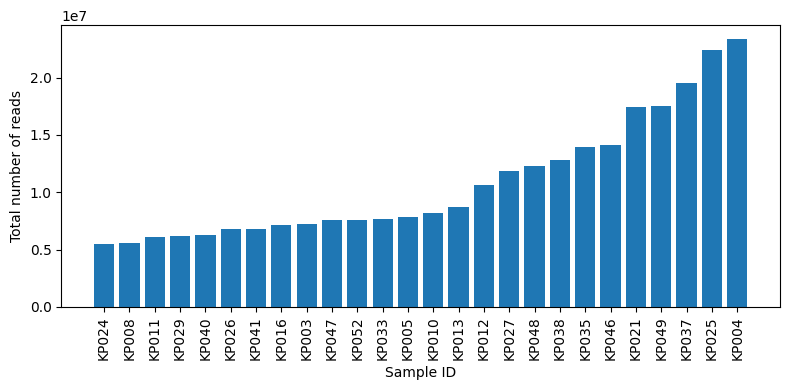

In [3]:
print(reads_nos)

sample_ids = list(reads_nos.keys())
values = [lst[-1]*2 for lst in reads_nos.values()]
sample_ids, values = zip(*sorted(zip(sample_ids, values), key=lambda x: x[1]))

plt.figure(figsize=(8, 4))
plt.bar(sample_ids, values)
plt.ylabel("Total number of reads")
plt.xlabel("Sample ID")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [4]:
#df_satur = process_data.species_richness_table(samp_list, reads_nos, path_in,
#                               evalue=1e-50, pident=0.99, taxa="species", tail_points=4, slope_thresh=0.00002)
#print(df_satur)

In [5]:
#df_satur.to_csv("/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/saturation_analysis_x4/saturation_summary.csv", index=False)

In [6]:
df_satur = process_data.species_richness_table(samp_list, reads_nos, path_in,
                               evalue=1e-50, pident=0.99, taxa="species", tail_points=5, slope_thresh=0.00002)
print(df_satur)

   Sample  Good's coverage Coverage status  Chao1 ratio   Chao1 status  \
0   KP003         0.997357       Saturated     0.662251      Saturated   
1   KP004         0.996213       Saturated     0.579630  Not saturated   
2   KP005         0.990161          Almost     0.573831  Not saturated   
3   KP008         0.996468       Saturated     0.660933      Saturated   
4   KP010         0.996683       Saturated     0.634618  Not saturated   
5   KP011         0.996212       Saturated     0.644184  Not saturated   
6   KP012         0.990399          Almost     0.576469  Not saturated   
7   KP013         0.995777          Almost     0.621184  Not saturated   
8   KP016         0.995537          Almost     0.697364      Saturated   
9   KP021         0.995493          Almost     0.592650  Not saturated   
10  KP024         0.995963          Almost     0.621423  Not saturated   
11  KP025         0.996606       Saturated     0.616786  Not saturated   
12  KP026         0.995255          Al

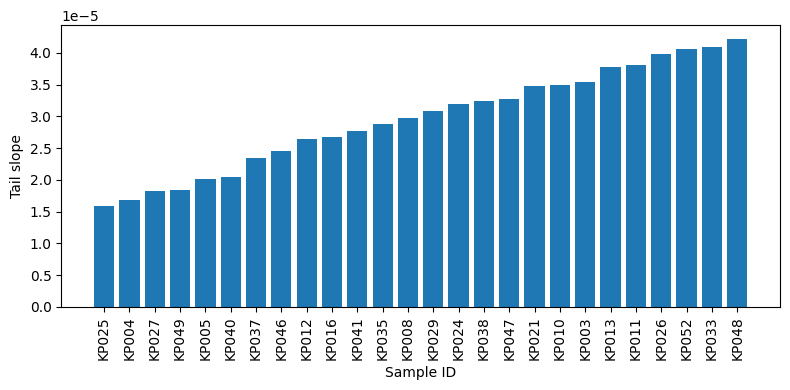

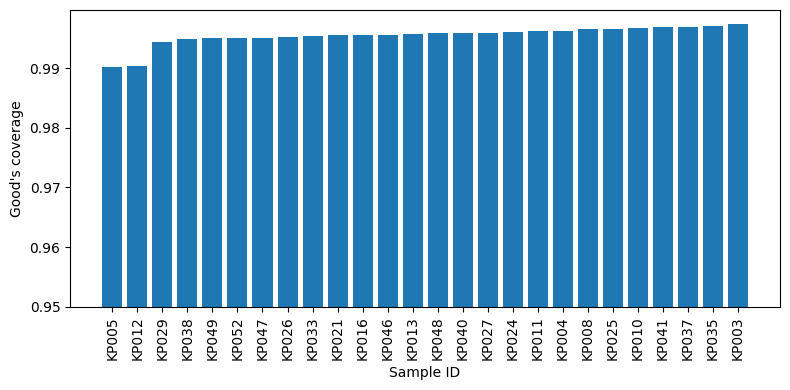

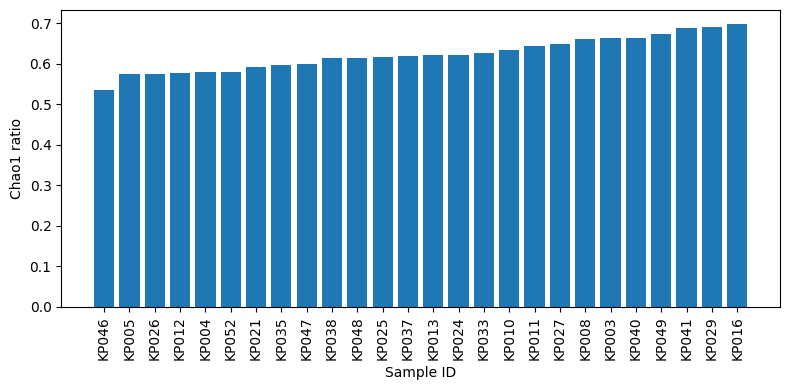

In [7]:
sample_ids = list(reads_nos.keys())
values = df_satur["Tail slope"]
sample_ids, values = zip(*sorted(zip(sample_ids, values), key=lambda x: x[1]))

plt.figure(figsize=(8, 4))
plt.bar(sample_ids, values)
plt.ylabel("Tail slope")
plt.xlabel("Sample ID")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

sample_ids = list(reads_nos.keys())
values = df_satur["Good's coverage"]-0.95
sample_ids, values = zip(*sorted(zip(sample_ids, values), key=lambda x: x[1]))

plt.figure(figsize=(8, 4))
plt.bar(sample_ids, values, bottom=0.95)
plt.ylabel("Good's coverage")
plt.xlabel("Sample ID")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

sample_ids = list(reads_nos.keys())
values = df_satur["Chao1 ratio"]
sample_ids, values = zip(*sorted(zip(sample_ids, values), key=lambda x: x[1]))

plt.figure(figsize=(8, 4))
plt.bar(sample_ids, values)
plt.ylabel("Chao1 ratio")
plt.xlabel("Sample ID")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

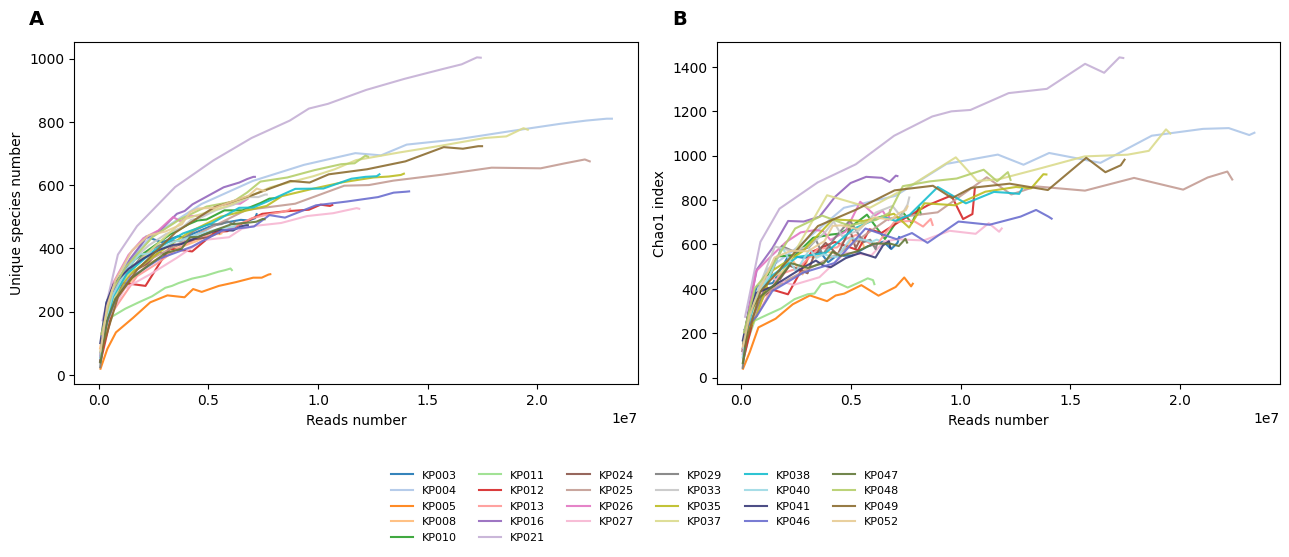

In [8]:
# more restrictive pruning
ev = 1e-200
pi = 0.99
path_out = path_in + "figs/saturation_curve_seqx6_ev" + str(ev) + "_pi" + str(pi) + ".png"
make_plots.saturation_curves(samp_list, reads_nos, path_in, path_out, evalue = ev, pident = pi, taxa="species")

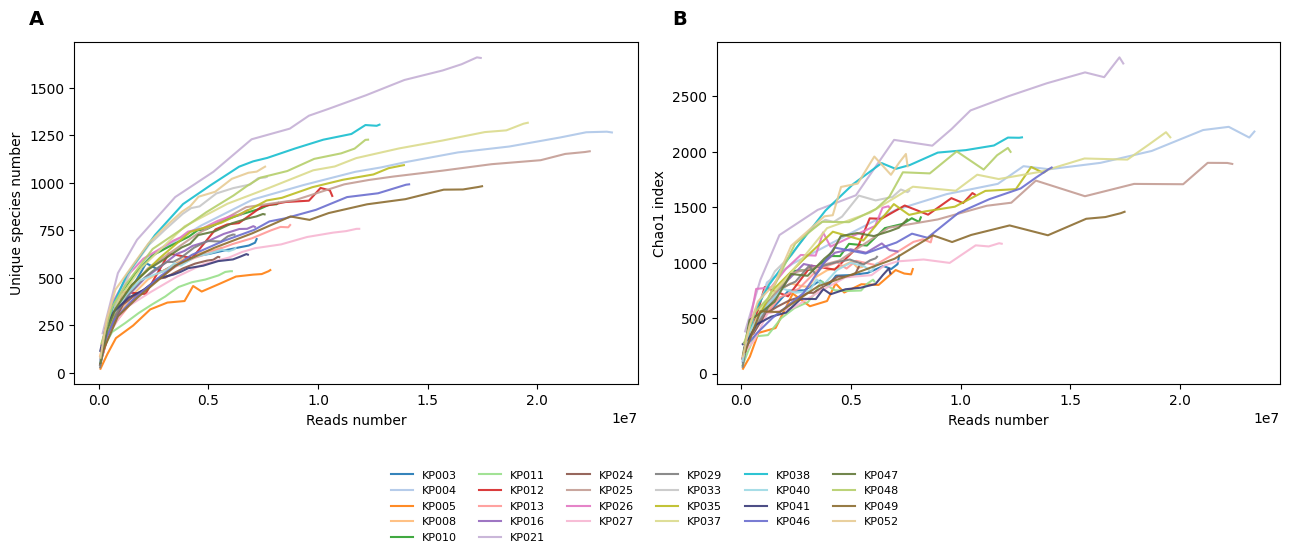

In [9]:
# less restrictive pruning
ev = 1e-50
pi = 0.99
path_out = path_in + "figs/saturation_curve_seqx6_ev" + str(ev) + "_pi" + str(pi) + ".png"
make_plots.saturation_curves(samp_list, reads_nos, path_in, path_out, evalue = ev, pident = pi, taxa="species")

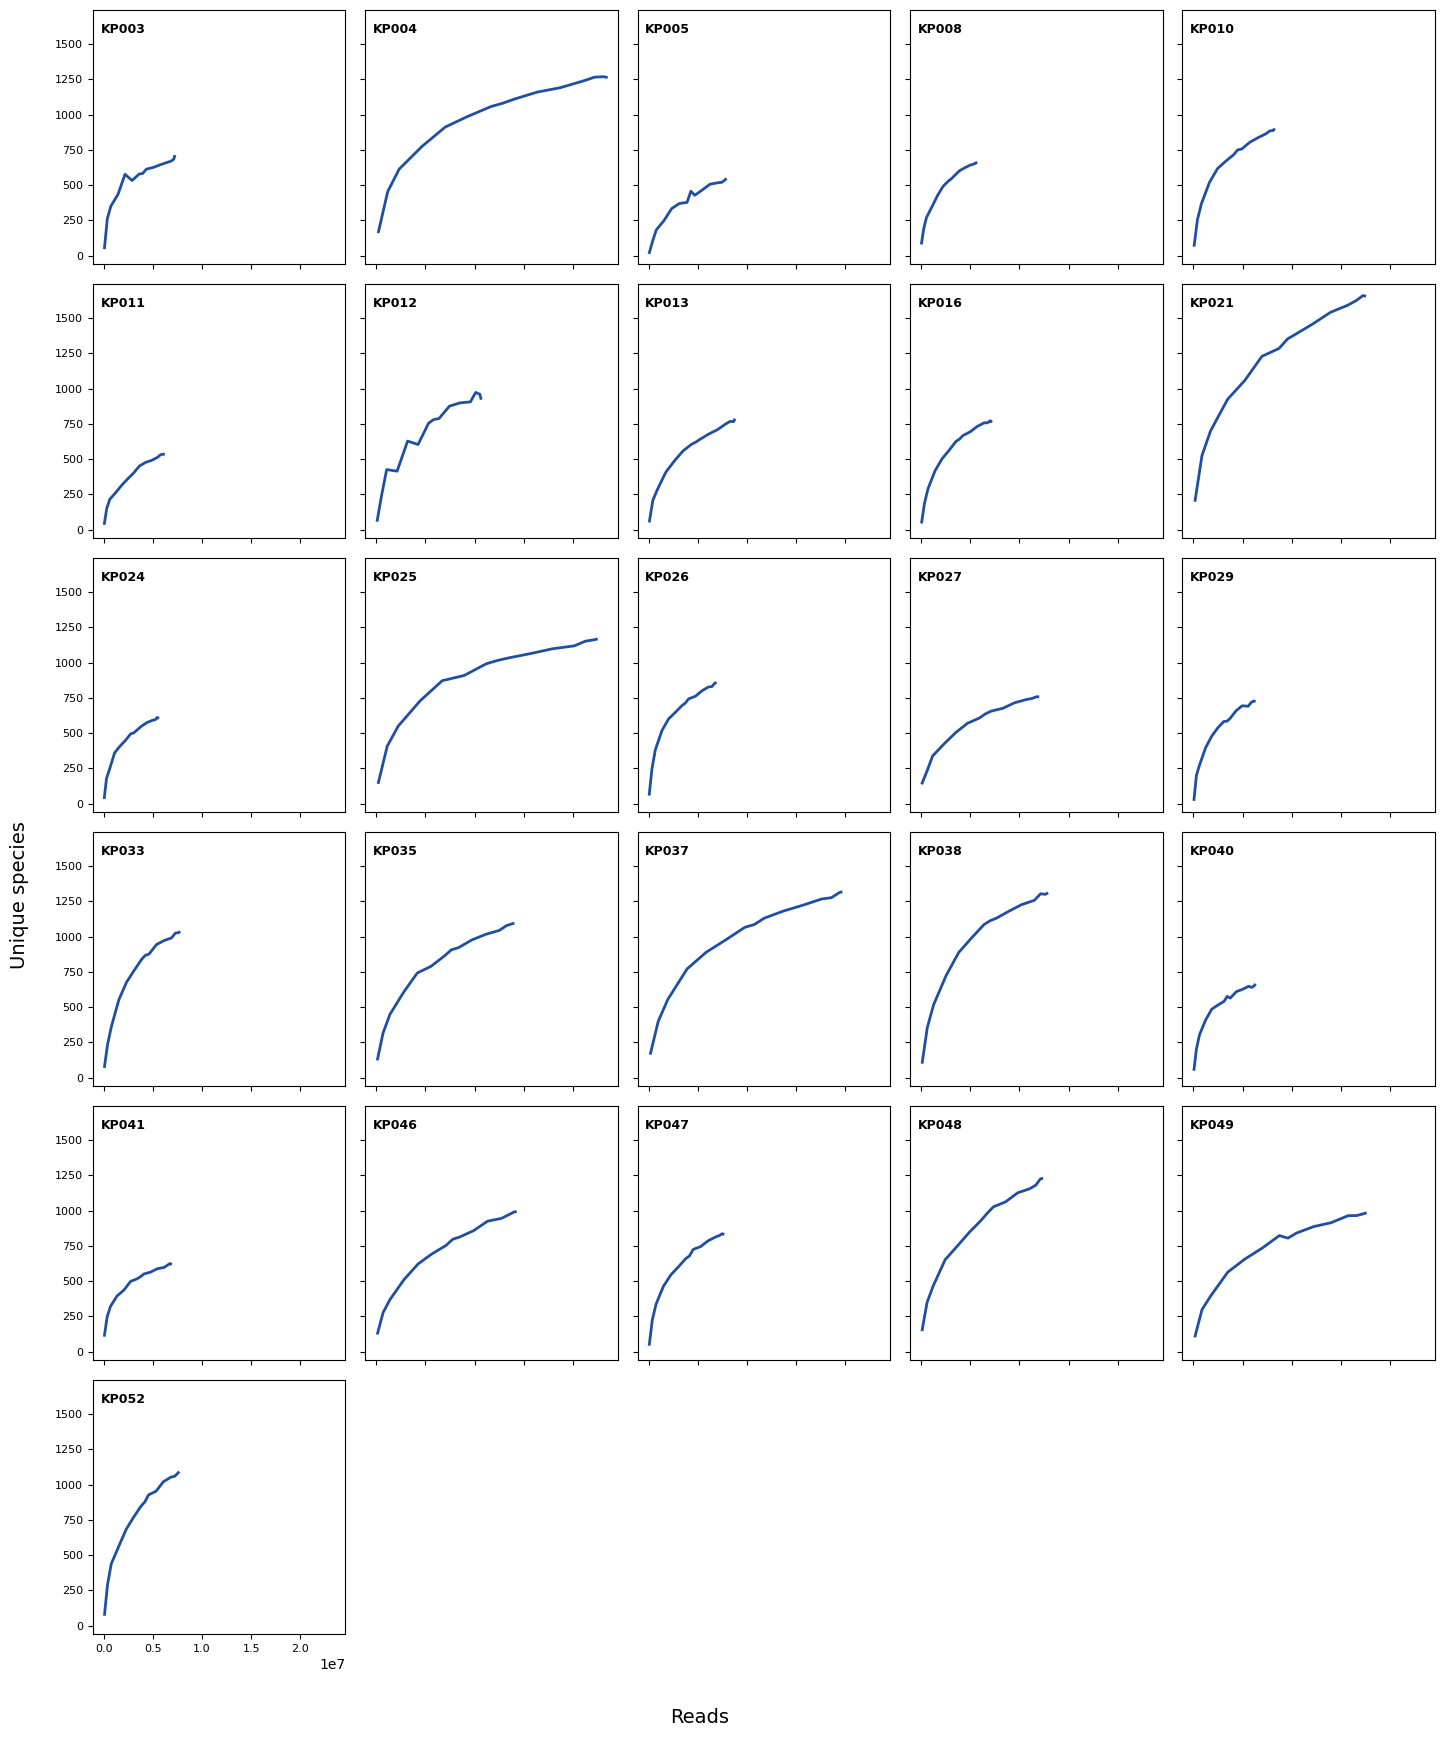

In [10]:
ev = 1e-50
pi = 0.99
path_out = path_in + "figs/multi_saturation_curve_seqx6_ev" + str(ev) + "_pi" + str(pi) + ".png"
make_plots.multi_saturation_curves(samp_list, reads_nos, path_in, path_out, evalue = ev, pident = pi, taxa="species")